In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ML-CaseStudy2-Dataset.csv to ML-CaseStudy2-Dataset.csv


In [ ]:
df = pd.read_csv("ML-CaseStudy2-Dataset.csv")
df.head()

,Employee_ID,Employee_Name,Age,Years_of_Experience,Monthly_Salary,Working_Hours_Per_Day,Projects_Handled,Job_Satisfaction,Department,City,Performance_Score,Attrition_Flag
0,11de2b9e-2148-4a1e-951b-1323d8f5f941,Austin Rodriguez,59.0,36,25860.0,11,13,6.37,sales,Pune,26.50,1
1,816703b6-7f5c-4511-8bf3-ace06d28333c,Stephanie Salazar,31.0,4,69131.0,11,8,6.86,IT,Mumbai,43.23,1
2,d10e1435-380e-4727-bab0-d1db39ea5e9e,Mrs. Jaclyn Chavez,22.0,0,87955.0,9,2,2.64,Human Resource,Mumbai,43.28,1
3,d8456859-9280-4bb0-a772-78952813e838,Susan Quinn,42.0,14,131970.0,13,12,9.76,sales,Chennai,77.60,1
4,791f7234-a526-4b85-adaa-70b4b01cbad8,Matthew Nelson,35.0,13,92435.0,10,4,6.33,sales,Hyderabad,58.22,0


In [ ]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(5050, 12)

Column Names:
Index(['Employee_ID', 'Employee_Name', 'Age', 'Years_of_Experience',
       'Monthly_Salary', 'Working_Hours_Per_Day', 'Projects_Handled',
       'Job_Satisfaction', 'Department', 'City', 'Performance_Score',
       'Attrition_Flag'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Employee_ID            5050 non-null   object 
 1   Employee_Name          5050 non-null   object 
 2   Age                    4950 non-null   float64
 3   Years_of_Experience    5050 non-null   int64  
 4   Monthly_Salary         4949 non-null   float64
 5   Working_Hours_Per_Day  5050 non-null   int64  
 6   Projects_Handled       5050 non-null   int64  
 7   Job_Satisfaction       4949 non-null   float64
 8   Department             5050 non-null   object 
 

In [ ]:
numerical_columns = df.select_dtypes(include=np.number).columns

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].mean())

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

Employee_ID              0
Employee_Name            0
Age                      0
Years_of_Experience      0
Monthly_Salary           0
Working_Hours_Per_Day    0
Projects_Handled         0
Job_Satisfaction         0
Department               0
City                     0
Performance_Score        0
Attrition_Flag           0
dtype: int64


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
label_encoder = LabelEncoder()

df['Age'] = label_encoder.fit_transform(df['Age'])

df['Years_of_Experience'] = label_encoder.fit_transform(df['Years_of_Experience'])

df.head()

,Employee_ID,Employee_Name,Age,Years_of_Experience,Monthly_Salary,Working_Hours_Per_Day,Projects_Handled,Job_Satisfaction,Department,City,Performance_Score,Attrition_Flag
0,11de2b9e-2148-4a1e-951b-1323d8f5f941,Austin Rodriguez,39,36,25860.0,11,13,6.37,sales,Pune,26.50,1
1,816703b6-7f5c-4511-8bf3-ace06d28333c,Stephanie Salazar,10,4,69131.0,11,8,6.86,IT,Mumbai,43.23,1
2,d10e1435-380e-4727-bab0-d1db39ea5e9e,Mrs. Jaclyn Chavez,1,0,87955.0,9,2,2.64,Human Resource,Mumbai,43.28,1
3,d8456859-9280-4bb0-a772-78952813e838,Susan Quinn,22,14,131970.0,13,12,9.76,sales,Chennai,77.60,1
4,791f7234-a526-4b85-adaa-70b4b01cbad8,Matthew Nelson,14,13,92435.0,10,4,6.33,sales,Hyderabad,58.22,0


In [ ]:
X = df.drop('Performance_Score', axis=1)
y = df['Performance_Score']

print("Independent Variables:")
print(X.head())

print("\nTarget Variable:")
print(y.head())

Independent Variables:
                            Employee_ID       Employee_Name  Age  \
0  11de2b9e-2148-4a1e-951b-1323d8f5f941    Austin Rodriguez   39   
1  816703b6-7f5c-4511-8bf3-ace06d28333c   Stephanie Salazar   10   
2  d10e1435-380e-4727-bab0-d1db39ea5e9e  Mrs. Jaclyn Chavez    1   
3  d8456859-9280-4bb0-a772-78952813e838         Susan Quinn   22   
4  791f7234-a526-4b85-adaa-70b4b01cbad8      Matthew Nelson   14   

   Years_of_Experience  Monthly_Salary  Working_Hours_Per_Day  \
0                   36         25860.0                     11   
1                    4         69131.0                     11   
2                    0         87955.0                      9   
3                   14        131970.0                     13   
4                   13         92435.0                     10   

   Projects_Handled  Job_Satisfaction      Department       City  \
0                13              6.37           sales       Pune   
1                 8              6.86    

In [ ]:
print(df.dtypes)
print(df.select_dtypes(include='object').columns)

Employee_ID               object
Employee_Name             object
Age                        int64
Years_of_Experience        int64
Monthly_Salary           float64
Working_Hours_Per_Day      int64
Projects_Handled           int64
Job_Satisfaction         float64
Department                object
City                      object
Performance_Score        float64
Attrition_Flag             int64
dtype: object
Index(['Employee_ID', 'Employee_Name', 'Department', 'City'], dtype='object')


In [ ]:
df.drop(columns=['id', 'ID', 'employee'], inplace=True, errors='ignore')

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Department'] = le.fit_transform(df['Department'])
df['City'] = le.fit_transform(df['City'])

**Objective:**
To predict the employee's Performance Score using Ridge Regression while reducing multicollinearity among independent variables.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:")
print(X_train.shape)

print("Testing Data Shape:")
print(X_test.shape)

Training Data Shape:
(4003, 11)
Testing Data Shape:
(1001, 11)


In [ ]:
print(X_train.columns.tolist())
print(X_train.dtypes)

['Employee_ID', 'Employee_Name', 'Age', 'Years_of_Experience', 'Monthly_Salary', 'Working_Hours_Per_Day', 'Projects_Handled', 'Job_Satisfaction', 'Department', 'City', 'Attrition_Flag']
Employee_ID               object
Employee_Name             object
Age                        int64
Years_of_Experience        int64
Monthly_Salary           float64
Working_Hours_Per_Day      int64
Projects_Handled           int64
Job_Satisfaction         float64
Department                object
City                      object
Attrition_Flag             int64
dtype: object


In [ ]:
X = df.drop(columns=['Monthly_Salary'])
y = df['Monthly_Salary']  # target

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in X.select_dtypes(include=['object']).columns:
    X[col] = le.fit_transform(X[col])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred = ridge.predict(X_test)
print("Done!")

Done!


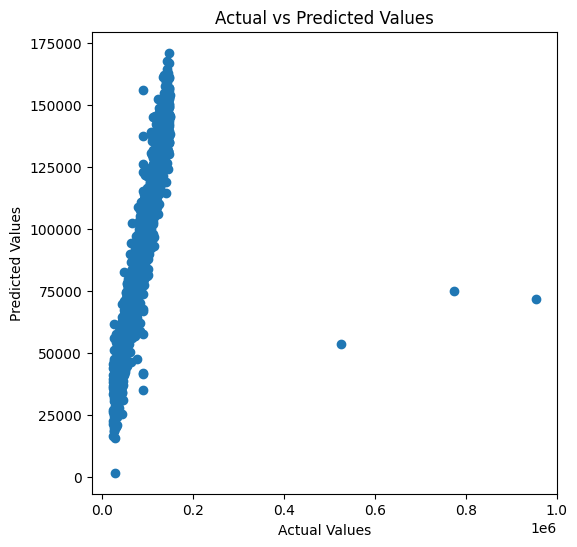

In [ ]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Values")

plt.show()

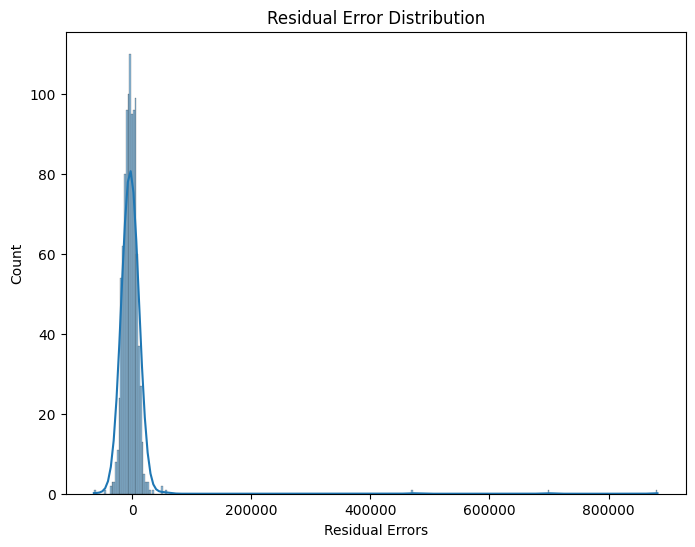

In [ ]:
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.title("Residual Error Distribution")
plt.xlabel("Residual Errors")
plt.show()

In [ ]:
comparison = pd.DataFrame({
    'Actual_Value': y_test.values,
    'Predicted_Value': y_pred
})


print(comparison.head(20))

     Actual_Value  Predicted_Value
0   139682.000000    129154.599556
1   123145.000000    129174.358027
2    29567.000000     31858.535008
3    53400.000000     74360.204234
4    66628.000000     75195.118624
5    25302.000000     35963.683361
6    91489.129117     57700.851793
7    49594.000000     55785.546092
8   145132.000000    150898.125140
9   133067.000000    150163.449572
10  135715.000000    161299.126623
11  114899.000000    121476.049786
12   32925.000000     24141.152912
13   97246.000000     98257.649550
14  103776.000000    113029.386920
15   74703.000000     70323.234394
16   73679.000000     90860.090342
17   30594.000000     54421.119389
18  106808.000000     93340.460907
19   41173.000000     57887.059272


Ridge Regression – Conclusion
Ridge Regression was applied to improve the performance of the regression model by reducing the effect of multicollinearity among independent variables. The regularization technique helped prevent overfitting and improved model stability. As a result, the model produced more reliable and accurate Performance Score predictions.